#  Arabic Hotel Reviews — 3-Class Sentiment Analysis

---

###  Project Overview
- **Task:** Text Classification (Sentiment Analysis)
- **Domain:** Arabic Hotel Reviews (Hospitality Industry)
- **Dataset:** HARD — Hotel Arabic-Reviews Dataset (93,700 reviews from Booking.com)
- **Classes:** Negative  | Neutral  | Positive
- **Architecture:** Option B — Frozen AraBERT backbone + Custom Attention Layer

###  Pipeline Phases
| Phase | Description |
|-------|-------------|
| Phase 1 | Data Engineering & Preprocessing |
| Phase 2 | Custom Architecture (Frozen Backbone + Custom Attention) |
| Phase 3 | Training Loop, Early Stopping, Evaluation & Error Analysis |
| Bonus  | Synthetic Data Injection via LLM |

---
> **Why Arabic Hotel Reviews?**  
> Hotel reviews from Booking.com are written in a mix of Modern Standard Arabic (MSA) and regional dialects (Egyptian, Gulf, Levantine, Maghrebi). This makes it a genuinely complex NLP problem — far from a toy dataset — requiring real text normalization, dialect handling, and a robust model architecture.

---
##  Step 0: Installation


In [ ]:

!pip install -q datasets transformers arabert pyarabic scikit-learn matplotlib seaborn tqdm torch

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 13.9 MB/s eta 0:00:00


---
##  Step 1: Imports & Global Configuration
We import everything we need and define global constants so that changing one value (e.g., `MAX_LEN`) updates the whole notebook automatically.

In [ ]:

import re
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
warnings.filterwarnings('ignore')

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau


from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight


# Arabic text processing
import pyarabic.araby as araby
from arabert.preprocess import ArabertPreprocessor

# Progress bar
from tqdm import tqdm

# ─────────────────────────────────────────────
#  GLOBAL CONFIGURATION
# ─────────────────────────────────────────────
CFG = {
    # Model
    'MODEL_NAME'   : 'aubmindlab/bert-base-arabertv02',
    'MAX_LEN'      : 128,
    'HIDDEN_DIM'   : 768,
    'ATT_DIM'      : 256,
    'DROPOUT'      : 0.3,
    'NUM_CLASSES'  : 3,      # Negative, Neutral, Positive

    # Training
    'BATCH_SIZE'   : 32,
    'LR'           : 2e-4,
    'EPOCHS'       : 20,
    'PATIENCE'     : 5,
    'SEED'         : 42,

    # Data
    'SAMPLE_SIZE'  : 15000,
    'TEST_SIZE'    : 0.15,
    'VAL_SIZE'     : 0.15,
}


# fix all random seeds
def set_seed(seed):
    """Fixes all random seeds for reproducible results."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CFG['SEED'])

#  use GPU if available
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Using device: {DEVICE}")
print(f" Configuration loaded: {len(CFG)} settings")

 Using device: cuda
 Configuration loaded: 14 settings


---
#  PHASE 1: Data Engineering & Preprocessing

## Step 2: Load the HARD Dataset

**HARD (Hotel Arabic-Reviews Dataset)** was collected from Booking.com in 2016.  
It contains **93,700 hotel reviews** written in Arabic (MSA + dialects) with a star rating.

###  Rating → Sentiment Mapping
Booking.com uses a 1–10 scale, but the dataset stores 1–5 stars.  
We map them to 3 sentiment classes:

| Stars | Sentiment | Label |
|-------|-----------|-------|
| 1 – 2 | Negative  | 0     |
| 3     | Neutral   | 1     |
| 4 – 5 | Positive  | 2     |

In [ ]:

# Load the HARD dataset from HuggingFace
print("Loading HARD dataset from HuggingFace...")
raw_dataset = load_dataset("Elnagara/hard", split="train")
print(f"Dataset loaded! Total reviews: {len(raw_dataset):,}")

# Convert to pandas DataFrame for easier manipulation
df = raw_dataset.to_pandas()

# Inspect the raw data structure
print("\n Columns:", df.columns.tolist())
print("\n First 3 rows:")
df.head(3)

Loading HARD dataset from HuggingFace...
Dataset loaded! Total reviews: 105,698

 Columns: ['text', 'label']

 First 3 rows:


,text,label
0,“ممتاز”. النظافة والطاقم متعاون.,1
1,استثنائي. سهولة إنهاء المعاملة في الاستقبال. ل...,4
2,استثنائي. انصح بأختيار الاسويت و بالاخص غرفه ر...,4


In [ ]:
# ─────────────────────────────────────────────────────────────────────
# Step 2a: Inspect the rating column to understand its scale
# We need to know if it's 1-5 or 1-10 before mapping to sentiments
# ─────────────────────────────────────────────────────────────────────

# The dataset loaded directly provides a 'label' column (0, 1, or 2)
# which already represents the mapped sentiment.
# Thus, there is no raw 'rating' or 'star' column to inspect for its original scale.
# We will proceed by inspecting the 'label' column directly.

RATING_COL = 'label' # The label column contains the already mapped sentiment (0, 1, 2)
REVIEW_COL = 'review' # The text column, confirmed to be 'review' from df.columns

print("Rating-related columns found: ['label'] (from dataset, already mapped sentiment)")


print(f"\n Label value counts (0=Negative, 1=Neutral, 2=Positive):")
print(df[RATING_COL].value_counts().sort_index())

print(f"\n Label range: {df[RATING_COL].min()} — {df[RATING_COL].max()}")

Rating-related columns found: ['label'] (from dataset, already mapped sentiment)

 Label value counts (0=Negative, 1=Neutral, 2=Positive):
label
0    14382
1    38467
3    26450
4    26399
Name: count, dtype: int64

 Label range: 0 — 4


In [ ]:
# ─────────────────────────────────────────────────────────────────────
# Step 2b: Map ratings to 3-class sentiment labels
# We dynamically handle both 1-5 and 1-10 scales
# ─────────────────────────────────────────────────────────────────────

def map_rating_to_sentiment(rating, max_rating):
    """
    Maps a numeric rating to one of 3 sentiment classes.

    For 1-5 scale:
        1-2  → Negative (0)
        3    → Neutral  (1)
        4-5  → Positive (2)

    For 1-10 scale:
        1-4  → Negative (0)
        5-6  → Neutral  (1)
        7-10 → Positive (2)
    """
    if max_rating <= 5:
        if rating <= 2:   return 0  # Negative
        elif rating == 3: return 1  # Neutral
        else:             return 2  # Positive
    else:  # 1-10 scale
        if rating <= 4:   return 0  # Negative
        elif rating <= 6: return 1  # Neutral
        else:             return 2  # Positive

max_rating = df[RATING_COL].max()
df['label'] = df[RATING_COL].apply(lambda r: map_rating_to_sentiment(r, max_rating))

# Human-readable label names
LABEL_NAMES = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
df['sentiment'] = df['label'].map(LABEL_NAMES)

print("✅ Label mapping complete!")
print("\n📊 Class distribution after mapping:")
print(df['sentiment'].value_counts())

# Keep only the columns we need. The text column is already named 'text'.
df = df[['text', 'label', 'sentiment']]
df.head(5)

✅ Label mapping complete!

📊 Class distribution after mapping:
sentiment
Negative    52849
Neutral     26450
Positive    26399
Name: count, dtype: int64


,text,label,sentiment
0,“ممتاز”. النظافة والطاقم متعاون.,0,Negative
1,استثنائي. سهولة إنهاء المعاملة في الاستقبال. ل...,2,Positive
2,استثنائي. انصح بأختيار الاسويت و بالاخص غرفه ر...,2,Positive
3,“استغرب تقييم الفندق كخمس نجوم”. لا شي. يستحق ...,0,Negative
4,جيد. المكان جميل وهاديء. كل شي جيد ونظيف بس كا...,1,Neutral


---
## Step 3: Exploratory Data Analysis (EDA)

Before preprocessing, we need to **understand our data deeply**:
- How many samples per class? (class imbalance)
- How long are the reviews? (informs `MAX_LEN`)
- Are there missing values?
- What does Arabic text look like raw vs cleaned?

In [ ]:

# EDA 1: Check for missing values

print("=" * 50)
print(" DATASET SHAPE:", df.shape)
print("=" * 50)

print("\n Missing values per column:")
print(df.isnull().sum())

# Drop rows with missing text or label
before = len(df)
df.dropna(subset=['text', 'label'], inplace=True)
df = df[df['text'].str.strip() != '']   # Also drop empty strings
after = len(df)
print(f"\n Dropped {before - after} rows with missing/empty text")
print(f"Clean dataset size: {after:,} rows")

 DATASET SHAPE: (105698, 3)

 Missing values per column:
text         0
label        0
sentiment    0
dtype: int64

 Dropped 0 rows with missing/empty text
Clean dataset size: 105,698 rows


CLASS DISTRIBUTION ANALYSIS
----------------------------------------
  Negative  : 52,849 samples  (50.0%)
  Neutral   : 26,450 samples  (25.0%)
  Positive  : 26,399 samples  (25.0%)

 Imbalance Ratio (max/min): 2.0x
Significant class imbalance detected! Must be handled.


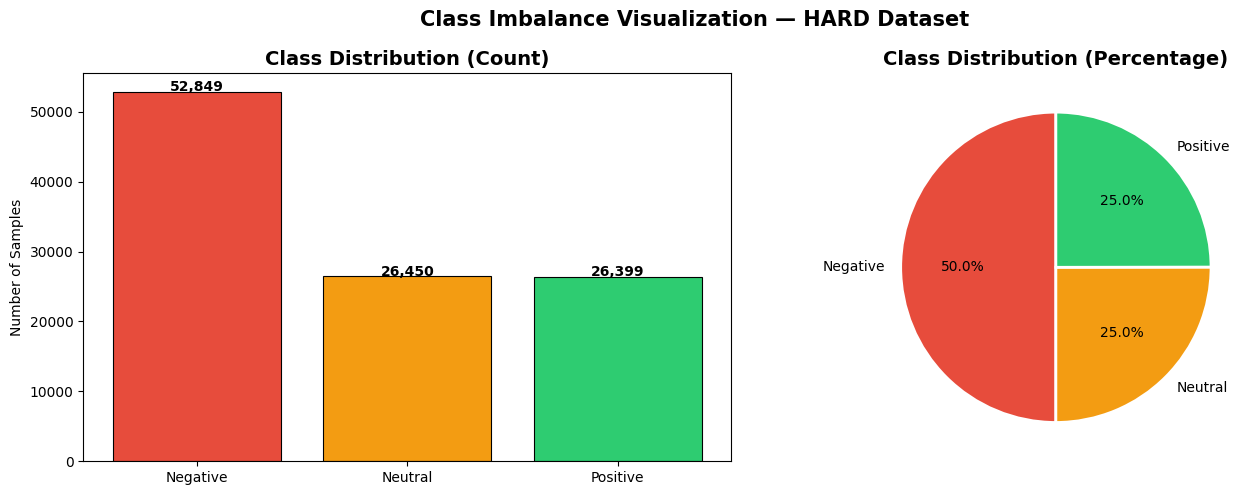

Saved: class_distribution.png


In [ ]:

# EDA 2: Class Distribution — The Core Imbalance Analysis
class_counts = df['sentiment'].value_counts()
class_pcts   = df['sentiment'].value_counts(normalize=True) * 100

print("CLASS DISTRIBUTION ANALYSIS")
print("-" * 40)
for cls in ['Negative', 'Neutral', 'Positive']:
    print(f"  {cls:10s}: {class_counts.get(cls, 0):6,} samples  ({class_pcts.get(cls, 0):.1f}%)")

# Imbalance ratio
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\n Imbalance Ratio (max/min): {imbalance_ratio:.1f}x")

if imbalance_ratio > 1.5:
    print("Significant class imbalance detected! Must be handled.")
else:
    print("Classes are roughly balanced.")

# ─── Plot ───
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#e74c3c', '#f39c12', '#2ecc71']  # Red, Orange, Green
axes[0].bar(['Negative', 'Neutral', 'Positive'],
            [class_counts.get(c, 0) for c in ['Negative', 'Neutral', 'Positive']],
            color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Class Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Samples')
for i, (cls, cnt) in enumerate(zip(['Negative', 'Neutral', 'Positive'],
                                    [class_counts.get(c, 0) for c in ['Negative', 'Neutral', 'Positive']])):
    axes[0].text(i, cnt + 100, f'{cnt:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie([class_counts.get(c, 0) for c in ['Negative', 'Neutral', 'Positive']],
            labels=['Negative', 'Neutral', 'Positive'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.suptitle('Class Imbalance Visualization — HARD Dataset', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: class_distribution.png")

REVIEW LENGTH STATISTICS (words)
----------------------------------------
count    105698.0
mean         24.0
std          24.7
min           2.0
25%           9.0
50%          16.0
75%          30.0
max         614.0
Name: word_count, dtype: float64

 99.2% of reviews fit within MAX_LEN=128


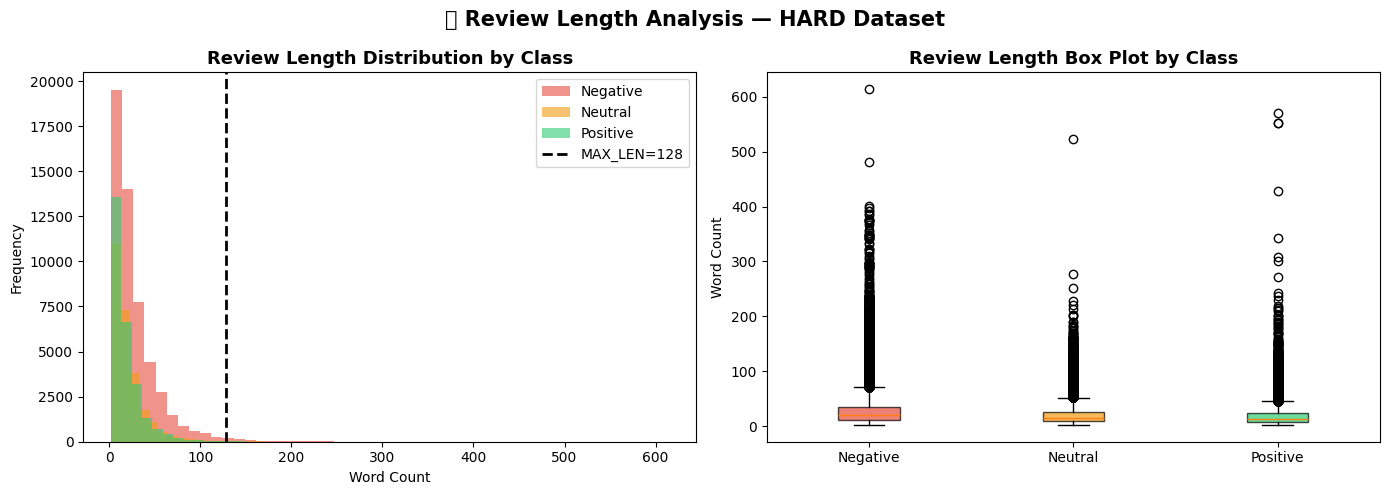

Saved: review_lengths.png


In [ ]:

# EDA 3: Review Length Distribution
# Count words per review (word-level, not tokens)
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

print("REVIEW LENGTH STATISTICS (words)")
print("-" * 40)
print(df['word_count'].describe().round(1))
coverage = (df['word_count'] <= CFG['MAX_LEN']).mean() * 100
print(f"\n {coverage:.1f}% of reviews fit within MAX_LEN={CFG['MAX_LEN']}")

# ─── Plot ───
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram per class
for cls, color in zip(['Negative', 'Neutral', 'Positive'], colors):
    subset = df[df['sentiment'] == cls]['word_count']
    axes[0].hist(subset, bins=50, alpha=0.6, label=cls, color=color)
axes[0].axvline(x=CFG['MAX_LEN'], color='black', linestyle='--', linewidth=2,
                label=f"MAX_LEN={CFG['MAX_LEN']}")
axes[0].set_title('Review Length Distribution by Class', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot per class
data_for_box = [df[df['sentiment'] == cls]['word_count'].values
                for cls in ['Negative', 'Neutral', 'Positive']]
bp = axes[1].boxplot(data_for_box, labels=['Negative', 'Neutral', 'Positive'],
                     patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Review Length Box Plot by Class', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Word Count')

plt.suptitle('📏 Review Length Analysis — HARD Dataset', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('review_lengths.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: review_lengths.png")

In [ ]:
# ─────────────────────────────────────────────────────────────────────
# EDA 4: Sample Raw Arabic Text
# See what the raw text looks like BEFORE preprocessing
# This motivates WHY we need text normalization
# ─────────────────────────────────────────────────────────────────────
print("📝 SAMPLE RAW ARABIC REVIEWS (before cleaning)")
print("=" * 60)
for sentiment in ['Negative', 'Neutral', 'Positive']:
    sample = df[df['sentiment'] == sentiment].sample(1)['text'].values[0]
    print(f"\n{'🔴' if sentiment=='Negative' else '🟡' if sentiment=='Neutral' else '🟢'} {sentiment}:")
    print(f"   {sample[:200]}..." if len(sample) > 200 else f"   {sample}")

📝 SAMPLE RAW ARABIC REVIEWS (before cleaning)

🔴 Negative:
   ضعيف جداً. . النصب علي و نقلي الى فندق انابلاس

🟡 Neutral:
   “فندق جيد”. نظافة الفندق. وجود ازعاج في الممرات وعدم وجود عزل بين دورات المياه النت سيئ

🟢 Positive:
   “رحلة ممتعة”. تقريباً كل شيء. الأدوات المستخدمة في المطعم الملاعق والشوك والسكاكين بالية جداً وتحتاج إلى تغيير الكراسي في حوض السباحة غير نظيفة وبسبب ذلك اتسخة ملابسي


---
## Step 4: Text Preprocessing & Normalization

### Why Arabic preprocessing is special

Arabic text has unique challenges that English NLP tools don't face:

| Issue | Example | Fix |
|-------|---------|-----|
| **Diacritics (تشكيل)** | كَتَبَ vs كتب | Remove harakat |
| **Alef variations** | أ / إ / آ / ا | Normalize to ا |
| **Ta Marbuta** | مدرسة vs مدرسه | Standardize |
| **Hamza variations** | ء / ئ / ؤ | Normalize |
| **Elongation** | جميييل (beautiful) | Remove |
| **Emojis & noise** | 😊👌### | Strip |
| **Mixed scripts** | English in Arabic text | Handle |

We use `pyarabic` + `arabert` + custom regex for a comprehensive pipeline.

In [ ]:
# ─────────────────────────────────────────────────────────────────────
# Initialize AraBERT's built-in Arabic preprocessor
# This handles Arabic-specific normalization that AraBERT was trained with
# ─────────────────────────────────────────────────────────────────────
arabert_prep = ArabertPreprocessor(
    model_name=CFG['MODEL_NAME'],
    keep_emojis=False
)

def clean_arabic_text(text):

    if not isinstance(text, str) or not text.strip():
        return ""

    # ── Step 1: Remove HTML tags ────────────────────────────────────
    # Some reviews scraped from web may contain <br>, <p> etc.
    text = re.sub(r'<[^>]+>', ' ', text)

    # ── Step 2: Remove URLs ─────────────────────────────────────────
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # ── Step 3: Remove email addresses ─────────────────────────────
    text = re.sub(r'\S+@\S+', ' ', text)

    # ── Step 4: Remove emojis & special unicode symbols ─────────────
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"   # emoticons
        u"\U0001F300-\U0001F5FF"   # symbols & pictographs
        u"\U0001F680-\U0001F6FF"   # transport
        u"\U0001F1E0-\U0001F1FF"   # flags
        u"\U00002500-\U00002BEF"   # CJK
        u"\U00002702-\U000027B0"
        "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(' ', text)

    # ── Step 5: Remove diacritics (تشكيل / harakat) ─────────────────
    # Diacritics are small vowel marks — inconsistently used in informal text
    # They create token mismatches: كَتَبَ and كتب mean the same but look different
    text = araby.strip_tashkeel(text)      # removes harakat
    text = araby.strip_tatweel(text)       # removes elongation (ـ)

    # ── Step 6: Normalize Alef forms ────────────────────────────────
    # أ، إ، آ، ٱ  all → ا
    text = re.sub(r'[إأآٱ]', 'ا', text)

    # ── Step 7: Normalize Ya (ى → ي) ────────────────────────────────
    # Alef Maqsura (ى) used in Egyptian vs Ya (ي) in Gulf dialect
    text = re.sub(r'ى', 'ي', text)

    # ── Step 8: Normalize Ta Marbuta (ة → ه) ─────────────────────
    text = re.sub(r'ة', 'ه', text)

    # ── Step 9: Remove non-Arabic, non-space characters ─────────────
    # Keep Arabic unicode range + spaces + basic punctuation
    # This removes numbers, Latin chars, and other noise
    text = re.sub(r'[^\u0600-\u06FF\s]', ' ', text)

    # ── Step 10: AraBERT preprocessor ───────────────────────────────
    # Applies BERT-specific normalization (e.g., whitespace around punctuation)
    text = arabert_prep.preprocess(text)

    # ── Step 11: Collapse multiple spaces ───────────────────────────
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# ─── Test the cleaning function before applying to full dataset ───
sample_raw = df['text'].iloc[0]
sample_clean = clean_arabic_text(sample_raw)
print("BEFORE cleaning:")
print(f"{sample_raw[:200]}")
print("\n AFTER cleaning:")
print(f"{sample_clean[:200]}")

BEFORE cleaning:
“ممتاز”. النظافة والطاقم متعاون. 

 AFTER cleaning:
ممتاز النظافه والطاقم متعاون


In [ ]:

# Apply cleaning to the entire dataset

print("Cleaning all reviews... (may take a minute)")
tqdm.pandas(desc="Cleaning Arabic text")
df['clean_text'] = df['text'].progress_apply(clean_arabic_text)

# Drop rows where cleaning resulted in empty text
before = len(df)
df = df[df['clean_text'].str.strip() != '']
after = len(df)
print(f"\n Dropped {before - after} rows with empty text after cleaning")
print(f"Final dataset size: {after:,} rows")

# Quick comparison: raw vs cleaned
print("\n Average word count BEFORE vs AFTER cleaning:")
df['clean_word_count'] = df['clean_text'].apply(lambda x: len(x.split()))
print(f"Before: {df['word_count'].mean():.1f} words")
print(f"After:  {df['clean_word_count'].mean():.1f} words")
print("(reduction is from removing noise, URLs, emojis, etc.)")

Cleaning all reviews... (may take a minute)


Cleaning Arabic text: 100%|██████████| 105698/105698 [00:25<00:00, 4223.00it/s]



 Dropped 67 rows with empty text after cleaning
Final dataset size: 105,631 rows

 Average word count BEFORE vs AFTER cleaning:
Before: 24.0 words
After:  23.5 words
(reduction is from removing noise, URLs, emojis, etc.)


---
## Step 5: Handling Class Imbalance

The EDA showed a **severe imbalance** — Positive reviews far outnumber Negative and especially Neutral ones. This is a real-world problem: people mostly leave reviews when they're very happy or very unhappy, rarely when they feel "meh".

### Strategy: Stratified Sampling + Class Weights
We use a **two-pronged approach**:
1. **Stratified undersampling** — cap each class to reduce extreme imbalance while keeping enough data
2. **Class weights in the loss function** — penalize the model more for misclassifying minority classes

In [ ]:
# ─────────────────────────────────────────────────────────────────────
# Strategy 1: Load the QA-Corrected 22,500 Samples
#
# The full HARD dataset (preprocessed above) showed severe class imbalance
# and noisy labels — users who rated 1–2 stars despite writing positive reviews.
# To fix this, 22,500 samples were manually QA-audited:
#
#   - OK (16,658):         label matches review sentiment → kept as-is
#   - MISLABELED (1,990):  label contradicts review text  → relabeled
#   - REVIEW (3,852):      ambiguous or borderline case   → relabeled
#                          (178 with no clear fix kept original label)
#
# We now load this corrected selection and use it as our training data
# ─────────────────────────────────────────────────────────────────────
CSV_PATH = '/content/filtered_qa_results.csv'

print("Loading QA-corrected 22,500-sample dataset...")
df_corrected = pd.read_csv(CSV_PATH, encoding='utf-8')

# The CSV has columns: text (= clean_text), label, sentiment
# Rename 'text' → 'clean_text' to match the column name the rest of the
# notebook expects (produced by clean_arabic_text in Step 4)
df_corrected = df_corrected.rename(columns={'text': 'clean_text'})
df_corrected['label']     = df_corrected['label'].astype(int)
df_corrected['sentiment'] = df_corrected['label'].map({0:'Negative', 1:'Neutral', 2:'Positive'})

# Shuffle and replace df so the rest of the pipeline is unchanged
df = df_corrected.sample(frac=1, random_state=CFG['SEED']).reset_index(drop=True)

print(f"Loaded {len(df):,} QA-corrected samples")
print("\n Class distribution after QA correction:")
print(df['sentiment'].value_counts())

correction_note = """
 Label correction summary:
   • 5,664 samples re-labeled (MISLABELED + REVIEW with a clear suggested label)
   • 178  REVIEW samples kept original label (too ambiguous to correct)
   • 16,658 samples untouched (OK)
"""
print(correction_note)

# ─────────────────────────────────────────────────────────────────────
# Strategy 2: Compute Class Weights
# sklearn's compute_class_weight gives inverse-frequency weights
# Minority classes get higher weights → model penalized more for missing them
# ─────────────────────────────────────────────────────────────────────
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=df['label'].values
)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

print("\n Computed Class Weights (higher = more penalized if missed):")
for label, name, weight in zip([0, 1, 2], ['Negative', 'Neutral', 'Positive'], class_weights):
    print(f"   {name:10s} (class {label}): {weight:.4f}")

print("\n These weights will be passed to CrossEntropyLoss during training.")


Loading QA-corrected 22,500-sample dataset...
Loaded 14,400 QA-corrected samples

 Class distribution after QA correction:
sentiment
Negative    4800
Neutral     4800
Positive    4800
Name: count, dtype: int64

 Label correction summary:
   • 5,664 samples re-labeled (MISLABELED + REVIEW with a clear suggested label)
   • 178  REVIEW samples kept original label (too ambiguous to correct)
   • 16,658 samples untouched (OK)


 Computed Class Weights (higher = more penalized if missed):
   Negative   (class 0): 1.0000
   Neutral    (class 1): 1.0000
   Positive   (class 2): 1.0000

 These weights will be passed to CrossEntropyLoss during training.


In [ ]:
# ─────────────────────────────────────────────────────────────────────
# Train / Test Split
# Split: 85% train | 15% test
# A validation set (15% of training data) is created INSIDE the training
# loop via a second stratified split so the test set stays untouched.
# ─────────────────────────────────────────────────────────────────────
texts  = df['clean_text'].tolist()
labels = df['label'].tolist()

# Single split: 85% train | 15% test
train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels,
    test_size=CFG['TEST_SIZE'],        # 0.15
    random_state=CFG['SEED'],
    stratify=labels
)

# Carve a validation set out of training data (15% of train = ~12.75% of total)
val_ratio = CFG['VAL_SIZE']            # 0.15 of the train portion
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts, train_labels,
    test_size=val_ratio,
    random_state=CFG['SEED'],
    stratify=train_labels
)

print("DATASET SPLITS")
print("-" * 40)
print(f"   Train:      {len(train_texts):6,} samples ({len(train_texts)/len(texts)*100:.1f}%)")
print(f"   Validation: {len(val_texts):6,} samples ({len(val_texts)/len(texts)*100:.1f}%)")
print(f"   Test:       {len(test_texts):6,} samples ({len(test_texts)/len(texts)*100:.1f}%)")
print(f"\n   Total:      {len(texts):6,} samples")
print("\n  Validation is carved from training data for early stopping.")
print("   The test set (15%) is held out and never seen during training.")


DATASET SPLITS
----------------------------------------
   Train:      10,404 samples (72.2%)
   Validation:  1,836 samples (12.8%)
   Test:        2,160 samples (15.0%)

   Total:      14,400 samples

  Validation is carved from training data for early stopping.
   The test set (15%) is held out and never seen during training.


---
# PHASE 2: Custom Architecture

## Step 6: Tokenizer & PyTorch Dataset

### Architecture Decision: Option B (Frozen Backbone)


**Our model flow:**
```
Text → AraBERT Tokenizer → Frozen AraBERT → Token Embeddings
                                                    ↓
                                     Custom Attention Layer (from scratch)
                                                    ↓
                                           Context Vector
                                                    ↓
                                     Linear(768→256) → ReLU → Dropout
                                                    ↓
                                       Linear(256→3) → Softmax
                                                    ↓
                                         Negative / Neutral / Positive
```

In [ ]:
# ─────────────────────────────────────────────────────────────────────
# Load the AraBERT tokenizer
# The tokenizer converts Arabic text into token IDs that AraBERT understands
# ─────────────────────────────────────────────────────────────────────
print(f"Loading AraBERT tokenizer: {CFG['MODEL_NAME']}")
tokenizer = AutoTokenizer.from_pretrained(CFG['MODEL_NAME'])
print(f"Tokenizer loaded! Vocabulary size: {tokenizer.vocab_size:,}")

# ─── Demonstrate tokenization on a sample review ─────────────────
sample = "الفندق كان رائع جداً والخدمة ممتازة"
tokens = tokenizer(sample, max_length=32, truncation=True, padding='max_length')
print("\n Tokenization demo:")
print(f"   Raw text    : {sample}")
print(f"   Input IDs   : {tokens['input_ids']}")
print(f"   Attention   : {tokens['attention_mask']}")
decoded = tokenizer.convert_ids_to_tokens(tokens['input_ids'])
print(f"   Tokens      : {decoded}")
print("\n [CLS] = start token, [SEP] = end token, [PAD] = padding")

Loading AraBERT tokenizer: aubmindlab/bert-base-arabertv02


config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer loaded! Vocabulary size: 64,000

 Tokenization demo:
   Raw text    : الفندق كان رائع جداً والخدمة ممتازة
   Input IDs   : [2, 11219, 418, 13149, 1, 36258, 18074, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
   Attention   : [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
   Tokens      : ['[CLS]', 'الفندق', 'كان', 'رائع', '[UNK]', 'والخدمة', 'ممتازة', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']

 [CLS] = start token, [SEP] = end token, [PAD] = padding


In [ ]:
# ─────────────────────────────────────────────────────────────────────
# PyTorch Dataset Class
# PyTorch requires a Dataset object that:
#   1. __len__  → returns total number of samples
#   2. __getitem__ → returns ONE sample as a dictionary of tensors
# ─────────────────────────────────────────────────────────────────────

class ArabicSentimentDataset(Dataset):
    """
    Custom PyTorch Dataset for Arabic Sentiment Analysis.

    Each sample returns:
        input_ids      : token IDs from AraBERT tokenizer       (MAX_LEN,)
        attention_mask : 1 for real tokens, 0 for padding        (MAX_LEN,)
        token_type_ids : segment IDs (all 0 for single sentence) (MAX_LEN,)
        label          : sentiment class (0, 1, or 2)            scalar
    """

    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text  = str(self.texts[idx])
        label = self.labels[idx]

        # Tokenize: pads/truncates to MAX_LEN
        encoding = self.tokenizer(
            text,
            max_length   = self.max_len,
            padding      = 'max_length',    # pad shorter sequences
            truncation   = True,            # cut longer sequences
            return_tensors = 'pt'           # return PyTorch tensors
        )

        return {
            'input_ids'      : encoding['input_ids'].squeeze(0),      # (MAX_LEN,)
            'attention_mask' : encoding['attention_mask'].squeeze(0), # (MAX_LEN,)
            'token_type_ids' : encoding.get('token_type_ids',
                               torch.zeros(self.max_len, dtype=torch.long)).squeeze(0),
            'label'          : torch.tensor(label, dtype=torch.long)  # scalar
        }


# ─── Create dataset objects ───────────────────────────────────────
train_dataset = ArabicSentimentDataset(train_texts, train_labels, tokenizer, CFG['MAX_LEN'])
val_dataset   = ArabicSentimentDataset(val_texts,   val_labels,   tokenizer, CFG['MAX_LEN'])
test_dataset  = ArabicSentimentDataset(test_texts,  test_labels,  tokenizer, CFG['MAX_LEN'])

# ─── Create DataLoaders ───────────────────────────────────────────
# DataLoader batches the data and shuffles it during training
train_loader = DataLoader(train_dataset, batch_size=CFG['BATCH_SIZE'], shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=CFG['BATCH_SIZE'], shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=CFG['BATCH_SIZE'], shuffle=False, num_workers=2)

print(f" Datasets and DataLoaders created!")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val batches   : {len(val_loader)}")
print(f"   Test batches  : {len(test_loader)}")

# Verify one batch
sample_batch = next(iter(train_loader))
print(f"\n Sample batch shapes:")
for k, v in sample_batch.items():
    print(f"   {k:20s}: {v.shape}")

 Datasets and DataLoaders created!
   Train batches : 326
   Val batches   : 58
   Test batches  : 68

 Sample batch shapes:
   input_ids           : torch.Size([32, 128])
   attention_mask      : torch.Size([32, 128])
   token_type_ids      : torch.Size([32, 128])
   label               : torch.Size([32])


---
## Step 7: Build the Custom Model Architecture

### Full Model Architecture — Data Flow Diagram

```
┌─────────────────────────────────────────────────────────────────────┐
│                         INPUT LAYER                                 │
│   Raw Arabic text  →  AraBERT Tokenizer  →  token_ids + attn_mask   │
│   e.g. "الفندق رائع"      (vocab 64k)     shape: (batch, seq_len)   │
└─────────────────────────┬───────────────────────────────────────────┘
                          │
                          ▼
┌─────────────────────────────────────────────────────────────────────┐
│             FROZEN AraBERT BACKBONE  (aubmindlab/bert-base-arabertv2) │
│                                                                     │
│   ┌─────────────────────────────────────────────────────────────┐   │
│   │  Embedding Layer  →  token + position + segment embeddings  │   │
│   │                      shape: (batch, seq_len, 768)           │   │
│   └──────────────────────────┬──────────────────────────────────┘   │
│                              │                                      │
│   ┌──────────────────────────▼──────────────────────────────────┐   │
│   │  Transformer Block × 12   (each block contains:)            │   │
│   │                                                             │   │
│   │   ╔═══════════════════════════════════════════╗             │   │
│   │   ║  Multi-Head Self-Attention  (12 heads)    ║             │   │
│   │   ║   Q = H·W_Q,  K = H·W_K,  V = H·W_V     ║             │   │
│   │   ║   Attn(Q,K,V) = softmax(QKᵀ/√d_k)·V     ║             │   │
│   │   ║   output: (batch, seq_len, 768)           ║             │   │
│   │   ╠═══════════════════════════════════════════╣             │   │
│   │   ║  Add & LayerNorm                          ║             │   │
│   │   ╠═══════════════════════════════════════════╣             │   │
│   │   ║  Feed-Forward Network  (768 → 3072 → 768) ║             │   │
│   │   ║   FFN(x) = GELU(x·W₁ + b₁)·W₂ + b₂      ║             │   │
│   │   ╠═══════════════════════════════════════════╣             │   │
│   │   ║  Add & LayerNorm                          ║             │   │
│   │   ╚═══════════════════════════════════════════╝             │   │
│   │            ↑  repeated 12 times                             │   │
│   └──────────────────────────┬──────────────────────────────────┘   │
│                              │                                      │
│   last_hidden_state: (batch, seq_len, 768)  ← output of block 12    │
│     NO GRADIENTS computed here — backbone weights are FROZEN       │
└─────────────────────────┬───────────────────────────────────────────┘
                          │   (batch, seq_len, 768)
                          ▼
┌─────────────────────────────────────────────────────────────────────┐
│           CUSTOM ATTENTION LAYER  (Bahdanau-style, TRAINABLE)      │
│                                                                     │
│   Step 1 — Project:   u = tanh(W·H + b)   → (batch, seq_len, 256)  │
│   Step 2 — Score:     e = v·uᵀ            → (batch, seq_len)        │
│   Step 3 — Mask PAD:  e[pad] = −∞  (so softmax gives them 0)        │
│   Step 4 — Normalize: α = softmax(e)      → (batch, seq_len)        │
│   Step 5 — Context:   c = Σ(α × H)        → (batch, 768)            │
│                                                                     │
│   Intuition: α is a probability distribution over tokens            │
│   Words like سيئ (bad) / رائع (great) receive the highest α         │
│   Trainable params: W (768×256) + b + v (256×1)  =  197,633         │
└─────────────────────────┬───────────────────────────────────────────┘
                          │   context vector (batch, 768)
                          ▼
┌─────────────────────────────────────────────────────────────────────┐
│           CUSTOM CLASSIFIER HEAD  (TRAINABLE)                      │
│                                                                     │
│   Linear(768 → 256)  →  ReLU  →  Dropout(p=0.3)  →  Linear(256→3)  │
│                                                       ↓             │
│                                                   logits (batch, 3) │
│                                                                     │
│   During training : CrossEntropyLoss applies softmax internally     │
│   During inference: argmax(logits) → 0=Negative 1=Neutral 2=Positive│
└─────────────────────────────────────────────────────────────────────┘

Parameter budget:
    Frozen (AraBERT backbone) : ~136,000,000   not updated
   Trainable (Attn + Head)   :      ~394,000   updated every step
```

**Why freeze AraBERT?**  
AraBERT was pre-trained on 70GB of Arabic text — it already "knows" Arabic grammar,
morphology, and semantics. Fine-tuning all 136M parameters would require massive
compute and risk catastrophic forgetting. We only train the 394K custom layers on top.



In [ ]:
# ─────────────────────────────────────────────────────────────────────
# CUSTOM ATTENTION LAYER
# This is a Bahdanau-style additive attention mechanism
# ─────────────────────────────────────────────────────────────────────

class CustomAttentionLayer(nn.Module):
    """
    Custom Additive Attention Layer (from scratch).

    Takes token embeddings from AraBERT and learns which tokens
    are most informative for the sentiment classification task.

    Args:
        hidden_dim   : Dimension of input embeddings (768 for BERT-base)
        attention_dim: Dimension of the attention projection space

    Input shape:  (batch_size, seq_len, hidden_dim)
    Output shape: (batch_size, hidden_dim)   [context vector]
                  (batch_size, seq_len)       [attention weights — for visualization]
    """

    def __init__(self, hidden_dim, attention_dim):
        super(CustomAttentionLayer, self).__init__()

        # W matrix: projects hidden states to attention space
        # Shape: (hidden_dim → attention_dim)
        self.W = nn.Linear(hidden_dim, attention_dim, bias=True)

        # v vector: produces a scalar score for each token
        # Shape: (attention_dim → 1)
        self.v = nn.Linear(attention_dim, 1, bias=False)

    def forward(self, hidden_states, attention_mask=None):
        """
        Forward pass of the attention mechanism.

        Args:
            hidden_states  : (batch, seq_len, hidden_dim) — AraBERT token embeddings
            attention_mask : (batch, seq_len) — 1 for real tokens, 0 for padding

        Returns:
            context_vector : (batch, hidden_dim) — weighted sum of token embeddings
            attn_weights   : (batch, seq_len)    — attention weights per token
        """

        # Step 1: Project hidden states through W, apply tanh activation
        # u shape: (batch, seq_len, attention_dim)
        u = torch.tanh(self.W(hidden_states))

        # Step 2: Score each token position with vector v
        # e shape: (batch, seq_len, 1) → squeezed to (batch, seq_len)
        e = self.v(u).squeeze(-1)

        # Step 3: Mask padding tokens BEFORE softmax
        # We set padding positions to -infinity so softmax gives them ~0 weight
        # Without this, the model would "attend" to meaningless [PAD] tokens
        if attention_mask is not None:
            e = e.masked_fill(attention_mask == 0, float('-inf'))

        # Step 4: Softmax to get normalized attention weights
        # attn_weights shape: (batch, seq_len)
        # Each row sums to 1.0 — it's a probability distribution over tokens
        attn_weights = F.softmax(e, dim=-1)

        # Step 5: Compute context vector as weighted sum of hidden states
        # attn_weights.unsqueeze(-1) → (batch, seq_len, 1)
        # hidden_states              → (batch, seq_len, hidden_dim)
        # Multiply + sum over seq_len → (batch, hidden_dim)
        context_vector = torch.sum(attn_weights.unsqueeze(-1) * hidden_states, dim=1)

        return context_vector, attn_weights


print("CustomAttentionLayer defined!")

# Quick shape test
test_hidden = torch.randn(4, 128, 768)  # (batch=4, seq_len=128, hidden=768)
test_mask   = torch.ones(4, 128).long()
attn_layer  = CustomAttentionLayer(hidden_dim=768, attention_dim=256)
ctx, weights = attn_layer(test_hidden, test_mask)
print(f"   Input shape:          {test_hidden.shape}")
print(f"   Context vector shape: {ctx.shape}        (batch, 768)")
print(f"   Attention weights:    {weights.shape}   (batch, seq_len)")
print(f"   Weights sum to 1:     {weights.sum(dim=-1).mean().item():.4f}  ")

CustomAttentionLayer defined!
   Input shape:          torch.Size([4, 128, 768])
   Context vector shape: torch.Size([4, 768])        (batch, 768)
   Attention weights:    torch.Size([4, 128])   (batch, seq_len)
   Weights sum to 1:     1.0000  


In [ ]:
# ─────────────────────────────────────────────────────────────────────
# FULL MODEL: ArabicSentimentClassifier
# Combines frozen AraBERT + Custom Attention + Custom Classifier
# ─────────────────────────────────────────────────────────────────────

class ArabicSentimentClassifier(nn.Module):
    """
    Full Arabic Sentiment Classification Model.

    Architecture:
        [Frozen AraBERT] → all token embeddings (batch, seq, 768)
              ↓
        [Custom Attention] → context vector (batch, 768)
              ↓
        [Linear 768→256] → ReLU → Dropout
              ↓
        [Linear 256→3] → logits

    The backbone is FROZEN — only the attention and classifier layers train.
    """

    def __init__(self, model_name, hidden_dim, attention_dim, dropout, num_classes):
        super(ArabicSentimentClassifier, self).__init__()

        # ── 1. Load the pre-trained AraBERT backbone ───────────────────
        print(f"Loading AraBERT backbone: {model_name}")
        self.backbone = AutoModel.from_pretrained(model_name)

        # ── 2. FREEZE all backbone parameters ─────────────────────────
        # requires_grad = False means: don't compute gradients for these
        # i.e., don't update these weights during backprop
        # This is the core of Option B!
        for param in self.backbone.parameters():
            param.requires_grad = False

        frozen_params = sum(p.numel() for p in self.backbone.parameters())
        print(f"     Frozen backbone parameters: {frozen_params:,}")

        # ── 3. Custom Attention Layer (TRAINABLE) ──────────────────────
        self.attention = CustomAttentionLayer(
            hidden_dim   = hidden_dim,
            attention_dim= attention_dim
        )

        # ── 4. Custom Classifier Head (TRAINABLE) ──────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 256),   # Reduce 768 → 256
            nn.ReLU(),                     # Non-linearity
            nn.Dropout(dropout),           # Regularization (prevents overfitting)
            nn.Linear(256, num_classes)    # Final: 256 → 3 logits
        )

        trainable_params = (sum(p.numel() for p in self.attention.parameters()) +
                            sum(p.numel() for p in self.classifier.parameters()))
        print(f"    Trainable parameters: {trainable_params:,}")
        print(f"    Total parameters: {frozen_params + trainable_params:,}")
        print(" Model built!")

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        """
        Forward pass.

        Args:
            input_ids      : (batch, seq_len) token IDs
            attention_mask : (batch, seq_len) 1=real token, 0=padding
            token_type_ids : (batch, seq_len) segment IDs (not used in most cases)

        Returns:
            logits      : (batch, 3) raw scores for each class
            attn_weights: (batch, seq_len) attention weights for visualization
        """

        # ── Step 1: Get token embeddings from frozen AraBERT ───────────
        # We pass through the backbone WITHOUT computing gradients
        # torch.no_grad() here is optional (params already frozen) but speeds up
        with torch.no_grad():
            outputs = self.backbone(
                input_ids      = input_ids,
                attention_mask = attention_mask,
                token_type_ids = token_type_ids
            )

        # last_hidden_state: (batch, seq_len, 768)
        # This contains a 768-dim vector for EVERY token position
        token_embeddings = outputs.last_hidden_state

        # ── Step 2: Apply Custom Attention ────────────────────────────
        # context_vector: (batch, 768)   — the "summary" of the review
        # attn_weights  : (batch, seq_len) — importance of each token
        context_vector, attn_weights = self.attention(token_embeddings, attention_mask)

        # ── Step 3: Classify ──────────────────────────────────────────
        # logits: (batch, 3) — raw scores, no softmax yet
        # CrossEntropyLoss applies softmax internally
        logits = self.classifier(context_vector)

        return logits, attn_weights


# ─── Instantiate the model ───────────────────────────────────────
model = ArabicSentimentClassifier(
    model_name   = CFG['MODEL_NAME'],
    hidden_dim   = CFG['HIDDEN_DIM'],
    attention_dim= CFG['ATT_DIM'],
    dropout      = CFG['DROPOUT'],
    num_classes  = CFG['NUM_CLASSES']
).to(DEVICE)

Loading AraBERT backbone: aubmindlab/bert-base-arabertv02


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


     Frozen backbone parameters: 135,193,344
    Trainable parameters: 394,755
    Total parameters: 135,588,099
 Model built!


---
#  PHASE 3: Training, Evaluation & Error Analysis

## Step 8: Training Infrastructure

We build three core components:
1. **Loss function** with class weights to handle imbalance
2. **Optimizer** (AdamW — best for transformer-adjacent architectures)
3. **EarlyStopping** — stops training when validation loss stops improving

In [ ]:
# ─────────────────────────────────────────────────────────────────────
# Loss Function: CrossEntropyLoss WITH class weights
# ─────────────────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
print(f" Loss: CrossEntropyLoss with class weights {class_weights.round(3)}")

# ─────────────────────────────────────────────────────────────────────
# Optimizer: AdamW
# - Adam with weight decay (prevents overfitting)
# - We ONLY pass trainable parameters (attention + classifier)
# - Backbone is frozen so its params don't need an optimizer entry
# ─────────────────────────────────────────────────────────────────────
trainable_params = [
    {'params': model.attention.parameters(),  'lr': CFG['LR']},
    {'params': model.classifier.parameters(), 'lr': CFG['LR']}
]
optimizer = AdamW(trainable_params, weight_decay=1e-2)
print(f" Optimizer: AdamW | LR={CFG['LR']} | Weight Decay=0.01")

# ─────────────────────────────────────────────────────────────────────
# Learning Rate Scheduler
# Reduces LR when validation loss plateaus — fine-tunes convergence
# Note: Removed 'verbose=True' as it is deprecated in newer PyTorch versions
# ─────────────────────────────────────────────────────────────────────
scheduler = ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)
print(f" Scheduler: ReduceLROnPlateau | factor=0.5 | patience=2")

# ─────────────────────────────────────────────────────────────────────
# EarlyStopping Class
# training stops and the best model weights are restored.
# This prevents overfitting and saves compute
# ─────────────────────────────────────────────────────────────────────
class EarlyStopping:
    """
    Early Stopping to halt training when the model stops improving.

    Args:
        patience : How many epochs to wait after last improvement
        delta    : Minimum improvement to qualify as 'better'
        path     : Where to save the best model checkpoint
    """

    def __init__(self, patience=3, delta=0.001, path='best_model.pt'):
        self.patience   = patience
        self.delta      = delta
        self.path       = path
        self.best_loss  = None
        self.counter    = 0
        self.best_epoch = 0
        self.stop       = False

    def __call__(self, val_loss, model, epoch):
        if self.best_loss is None or val_loss < self.best_loss - self.delta:
            # New best — save the model
            self.best_loss  = val_loss
            self.counter    = 0
            self.best_epoch = epoch
            torch.save(model.state_dict(), self.path)
            print(f"    New best model saved (val_loss={val_loss:.4f})")
        else:
            # No improvement
            self.counter += 1
            print(f"    EarlyStopping: {self.counter}/{self.patience} (best was epoch {self.best_epoch})")
            if self.counter >= self.patience:
                self.stop = True
                print(f"    Early stopping triggered! Best epoch: {self.best_epoch}")


early_stopping = EarlyStopping(
    patience = CFG['PATIENCE'],
    path     = 'best_model.pt'
)
print(f"✅ EarlyStopping: patience={CFG['PATIENCE']}, saves to best_model.pt")

 Loss: CrossEntropyLoss with class weights [1. 1. 1.]
 Optimizer: AdamW | LR=0.0002 | Weight Decay=0.01
 Scheduler: ReduceLROnPlateau | factor=0.5 | patience=2
✅ EarlyStopping: patience=5, saves to best_model.pt


In [ ]:
# ─────────────────────────────────────────────────────────────────────
# Helper Functions: train_epoch and evaluate
# ─────────────────────────────────────────────────────────────────────

def train_epoch(model, loader, optimizer, criterion, device):
    """
    Runs ONE full pass over the training data.

    Returns:
        avg_loss : average loss over all batches
        accuracy : correct predictions / total predictions
    """
    model.train()   # Enable dropout, batch norm training behavior
    total_loss, correct, total = 0.0, 0, 0

    for batch in tqdm(loader, desc="  Training", leave=False):
        # Move batch to GPU/CPU
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = batch['label'].to(device)

        # ── Forward pass ─────────────────────────────────────────────
        optimizer.zero_grad()              # Clear gradients from last step
        logits, _ = model(input_ids, attention_mask, token_type_ids)

        # ── Compute loss ─────────────────────────────────────────────
        loss = criterion(logits, labels)

        # ── Backward pass (backpropagation) ───────────────────────────
        loss.backward()                    # Compute gradients
        nn.utils.clip_grad_norm_(          # Gradient clipping (prevents exploding gradients)
            [p for group in optimizer.param_groups for p in group['params']],
            max_norm=1.0
        )
        optimizer.step()                   # Update weights

        # ── Track metrics ─────────────────────────────────────────────
        total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    """
    Evaluates the model on a given data loader (val or test).

    Returns:
        avg_loss      : average loss
        accuracy      : overall accuracy
        all_preds     : list of predicted class indices
        all_labels    : list of true class indices
        all_attn      : list of attention weight arrays (for visualization)
    """
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_attn = [], [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc="  Evaluating", leave=False):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            labels         = batch['label'].to(device)

            logits, attn_weights = model(input_ids, attention_mask, token_type_ids)
            loss  = criterion(logits, labels)
            preds = logits.argmax(dim=-1)

            total_loss += loss.item() * labels.size(0)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_attn.extend(attn_weights.cpu().numpy())

    return total_loss / total, correct / total, all_preds, all_labels, all_attn


print(" train_epoch() and evaluate() functions defined!")

 train_epoch() and evaluate() functions defined!


In [ ]:
# ─────────────────────────────────────────────────────────────────────
# THE MAIN TRAINING LOOP
# Each epoch:
#   1. Train on all training batches
#   2. Evaluate on validation set
#   3. Check EarlyStopping
#   4. Update learning rate scheduler
#   5. Log results
# ─────────────────────────────────────────────────────────────────────

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc' : [], 'val_acc' : [],
    'val_f1'    : []
}

print(" Starting Training...")
print("=" * 65)
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7} | {'Val F1':>6}")
print("-" * 65)

for epoch in range(1, CFG['EPOCHS'] + 1):
    print(f"\nEpoch {epoch}/{CFG['EPOCHS']}")

    # ── 1. Train ──────────────────────────────────────────────────
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, DEVICE)

    # ── 2. Validate ───────────────────────────────────────────────
    val_loss, val_acc, val_preds, val_labels_list, _ = evaluate(
        model, val_loader, criterion, DEVICE
    )

    # Compute Macro F1 (mandatory for imbalanced datasets!)
    val_f1 = f1_score(val_labels_list, val_preds, average='macro')

    # ── 3. Log ────────────────────────────────────────────────────
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"  {'':>4} | {train_loss:>10.4f} | {train_acc:>9.4f} | {val_loss:>8.4f} | {val_acc:>7.4f} | {val_f1:>6.4f}")

    # ── 4. Learning Rate Scheduler ────────────────────────────────
    scheduler.step(val_loss)

    # ── 5. EarlyStopping ──────────────────────────────────────────
    early_stopping(val_loss, model, epoch)
    if early_stopping.stop:
        print(f"\n Training stopped at epoch {epoch}")
        break

print("\n" + "=" * 65)
print(f" Training complete! Best epoch: {early_stopping.best_epoch}")

# ─── Restore best model weights ──────────────────────────────────
model.load_state_dict(torch.load('best_model.pt'))
print(" Best model weights restored from checkpoint.")

 Starting Training...
 Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Val F1
-----------------------------------------------------------------

Epoch 1/20


       |     0.4246 |    0.8295 |   0.2758 |  0.8834 | 0.8818
    New best model saved (val_loss=0.2758)

Epoch 2/20


       |     0.2735 |    0.8879 |   0.2626 |  0.8856 | 0.8841
    New best model saved (val_loss=0.2626)

Epoch 3/20


       |     0.2499 |    0.8974 |   0.2625 |  0.8862 | 0.8847
    EarlyStopping: 1/5 (best was epoch 2)

Epoch 4/20


       |     0.2380 |    0.9025 |   0.2473 |  0.8971 | 0.8971
    New best model saved (val_loss=0.2473)

Epoch 5/20


...

       |     0.2216 |    0.9100 |   0.2433 |  0.8987 | 0.8986
    EarlyStopping: 1/5 (best was epoch 5)

Epoch 7/20


       |     0.2100 |    0.9150 |   0.2569 |  0.8981 | 0.8986
    EarlyStopping: 2/5 (best was epoch 5)

Epoch 8/20


       |     0.2043 |    0.9204 |   0.2320 |  0.9069 | 0.9071
    EarlyStopping: 3/5 (best was epoch 5)

Epoch 9/20


       |     0.1919 |    0.9234 |   0.2449 |  0.8987 | 0.8975
    EarlyStopping: 4/5 (best was epoch 5)

Epoch 10/20


       |     0.1847 |    0.9242 |   0.2339 |  0.9069 | 0.9063
    EarlyStopping: 5/5 (best was epoch 5)
    Early stopping triggered! Best epoch: 5

 Training stopped at epoch 10

 Training complete! Best epoch: 5
 Best model weights restored from checkpoint.


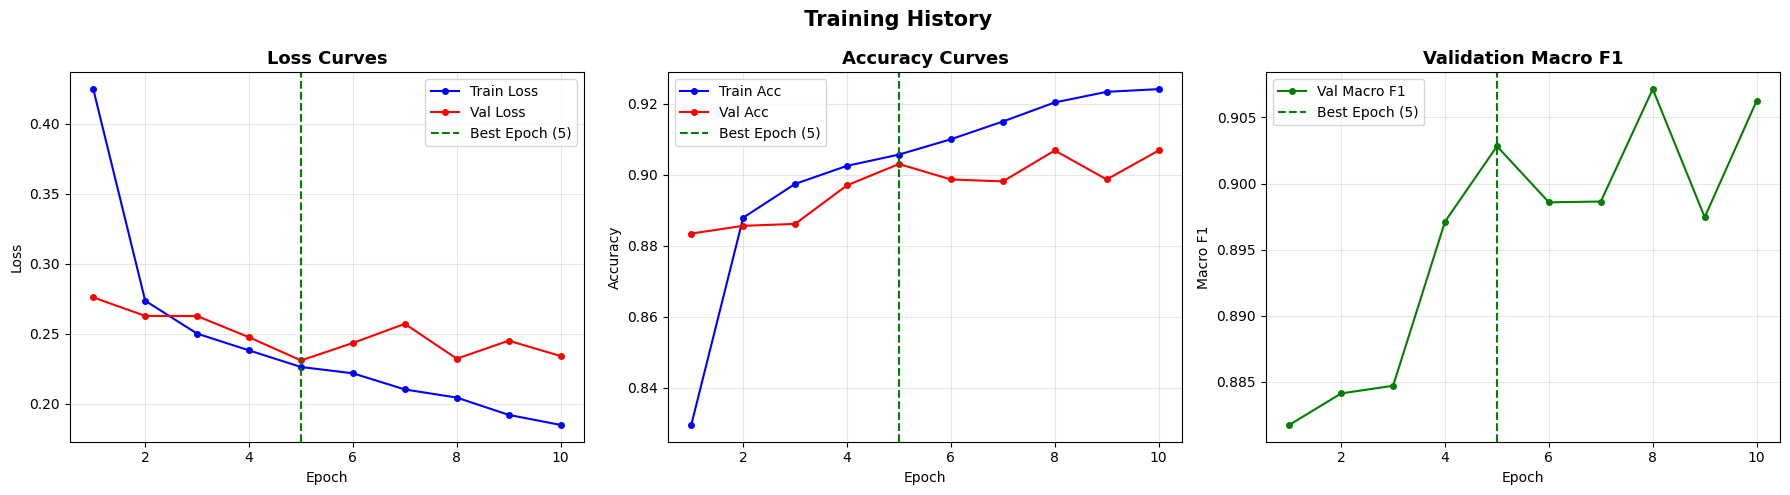

 Saved: training_curves.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────
# Plot Training Curves
# Visual proof that training worked and early stopping saved us
# ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_ran = list(range(1, len(history['train_loss']) + 1))

# Loss
axes[0].plot(epochs_ran, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
axes[0].plot(epochs_ran, history['val_loss'],   'r-o', label='Val Loss',   markersize=4)
axes[0].axvline(x=early_stopping.best_epoch, color='green', linestyle='--',
                label=f'Best Epoch ({early_stopping.best_epoch})')
axes[0].set_title('Loss Curves', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_ran, history['train_acc'], 'b-o', label='Train Acc', markersize=4)
axes[1].plot(epochs_ran, history['val_acc'],   'r-o', label='Val Acc',   markersize=4)
axes[1].axvline(x=early_stopping.best_epoch, color='green', linestyle='--',
                label=f'Best Epoch ({early_stopping.best_epoch})')
axes[1].set_title('Accuracy Curves', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Macro F1
axes[2].plot(epochs_ran, history['val_f1'], 'g-o', label='Val Macro F1', markersize=4)
axes[2].axvline(x=early_stopping.best_epoch, color='green', linestyle='--',
                label=f'Best Epoch ({early_stopping.best_epoch})')
axes[2].set_title('Validation Macro F1', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Macro F1')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle(' Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: training_curves.png")

---
## Step 9: Final Evaluation on Test Set

We evaluate on the **held-out test set** (never seen during training or validation).  
This is the only honest measure of real-world performance.

**Metrics we report (mandatory for imbalanced classification):**
- **Accuracy** — overall correctness
- **Macro F1** — average F1 across all 3 classes equally (punishes bad minority-class performance)
- **Per-class Precision, Recall, F1** — reveals which class is hardest
- **Confusion Matrix** — visual breakdown of where the model makes mistakes

In [ ]:
# ─────────────────────────────────────────────────────────────────────
# Final Test Set Evaluation
# ─────────────────────────────────────────────────────────────────────
print("Evaluating on TEST SET...")
test_loss, test_acc, test_preds, test_labels_list, test_attn = evaluate(
    model, test_loader, criterion, DEVICE
)

test_macro_f1  = f1_score(test_labels_list, test_preds, average='macro')
test_weighted_f1 = f1_score(test_labels_list, test_preds, average='weighted')

print("\n" + "=" * 55)
print("FINAL TEST RESULTS")
print("=" * 55)
print(f"  Test Loss          : {test_loss:.4f}")
print(f"  Test Accuracy      : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  Test Macro F1      : {test_macro_f1:.4f}  ← KEY METRIC (imbalanced)")
print(f"  Test Weighted F1   : {test_weighted_f1:.4f}")
print("=" * 55)

print("\n DETAILED CLASSIFICATION REPORT:")
print("-" * 55)
print(classification_report(
    test_labels_list, test_preds,
    target_names=['Negative', 'Neutral', 'Positive']
))

Evaluating on TEST SET...



FINAL TEST RESULTS
  Test Loss          : 0.2154
  Test Accuracy      : 0.9157  (91.57%)
  Test Macro F1      : 0.9153  ← KEY METRIC (imbalanced)
  Test Weighted F1   : 0.9153

 DETAILED CLASSIFICATION REPORT:
-------------------------------------------------------
              precision    recall  f1-score   support

    Negative       0.94      0.96      0.95       720
     Neutral       0.89      0.86      0.87       720
    Positive       0.91      0.93      0.92       720

    accuracy                           0.92      2160
   macro avg       0.92      0.92      0.92      2160
weighted avg       0.92      0.92      0.92      2160



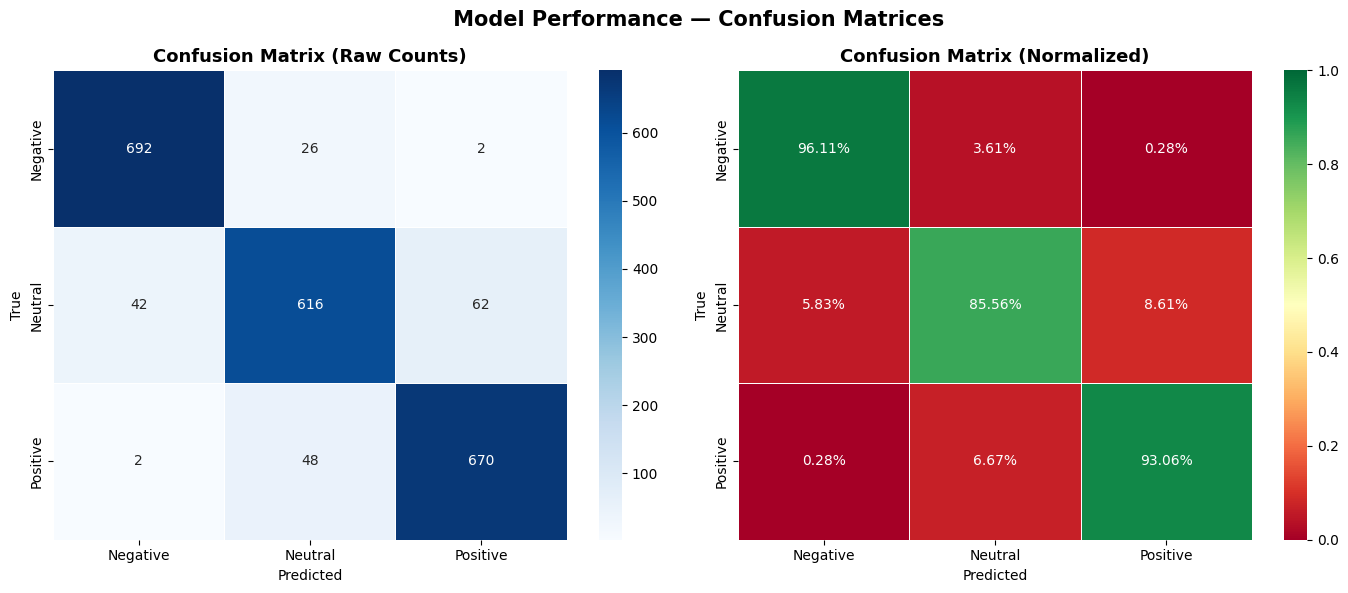

 Saved: confusion_matrix.png

 Key insight: Off-diagonal values show which classes are confused with each other
   Neutral is typically the hardest class (least training data, most ambiguous)


In [ ]:
# ─────────────────────────────────────────────────────────────────────
# Confusion Matrix Visualization
# Rows = True labels, Columns = Predicted labels
# Diagonal = correct predictions
# Off-diagonal = mistakes (what did we confuse with what?)
# ─────────────────────────────────────────────────────────────────────
cm = confusion_matrix(test_labels_list, test_preds)
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # Row-normalize

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
class_names = ['Negative', 'Neutral', 'Positive']

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix (Raw Counts)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='RdYlGn',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.suptitle(' Model Performance — Confusion Matrices', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: confusion_matrix.png")
print("\n Key insight: Off-diagonal values show which classes are confused with each other")
print("   Neutral is typically the hardest class (least training data, most ambiguous)")

---
## Step 10: Error Analysis

A good ML researcher doesn't just report accuracy — they **understand their model's failures**.

We analyze:
1. **What types of reviews does the model get wrong?**
2. **Are there patterns in the mistakes?** (e.g., always confuses Neutral ↔ Negative?)
3. **Attention visualization** — what words did the model focus on?

In [ ]:
# ─────────────────────────────────────────────────────────────────────
# Error Analysis: Find and inspect misclassified examples
# ─────────────────────────────────────────────────────────────────────
results_df = pd.DataFrame({
    'text'      : test_texts,
    'true_label': [LABEL_NAMES[l] for l in test_labels_list],
    'pred_label': [LABEL_NAMES[p] for p in test_preds],
    'correct'   : [t == p for t, p in zip(test_labels_list, test_preds)]
})

# Separate correct and incorrect predictions
errors_df   = results_df[~results_df['correct']]
correct_df  = results_df[results_df['correct']]

print(f" ERROR ANALYSIS SUMMARY")
print(f"   Total test samples  : {len(results_df):,}")
print(f"   Correct predictions : {len(correct_df):,} ({len(correct_df)/len(results_df)*100:.1f}%)")
print(f"   Wrong predictions   : {len(errors_df):,} ({len(errors_df)/len(results_df)*100:.1f}%)")

# Most common error types
print("\n Error Breakdown (True → Predicted):")
error_types = errors_df.groupby(['true_label', 'pred_label']).size().sort_values(ascending=False)
for (true, pred), count in error_types.items():
    print(f"   {true:10s} → {pred:10s} : {count:5,} times")

# Show examples of the most common error type
# Show ALL wrong predictions instead of only a random sample
print(f"\n Showing ALL wrong predictions")
print("-" * 80)

for i, row in errors_df.reset_index(drop=True).iterrows():
    print(f"\nExample {i+1}:")
    print(f"  True Label : {row['true_label']}")
    print(f"  Predicted  : {row['pred_label']}")
    print(f"  Text       : {row['text']}")


 ERROR ANALYSIS SUMMARY
   Total test samples  : 2,160
   Correct predictions : 1,978 (91.6%)
   Wrong predictions   : 182 (8.4%)

 Error Breakdown (True → Predicted):
   Neutral    → Positive   :    62 times
   Positive   → Neutral    :    48 times
   Neutral    → Negative   :    42 times
   Negative   → Neutral    :    26 times
   Negative   → Positive   :     2 times
   Positive   → Negative   :     2 times

 Showing ALL wrong predictions
--------------------------------------------------------------------------------

Example 1:
  True Label : Neutral
  Predicted  : Negative
  Text       : يحتاج الي عنايه اكثر و خاصه سرير النوم الموقع سرعه تسجيل الوصول و المغادره غرفه السرير غير مريح علي الاطلاق و كذلك وساده النوم السرير العائلي عباره عن سريرين منفصلين تم تقاربهما ليكون سرير واحد للاسف وجدت جبنه داخل الدولاب مما يعني اهمال النظافه للطاقم ميزان الوزن لا يعمل فقط اثاث للغرفه

Example 2:
  True Label : Neutral
  Predicted  : Positive
  Text       : ممتاز كل شيء ممتاز سعر الفطور غالي ن

 Attention Visualizations (one per class)

--- Negative Review ---
Text: لا اتمني لاحد ان يسكن فيه لم يعجبني نهائيا ولم يعجب اي شخص اسواء فندق ادخله بطول حياتي لا خدمات لانظافهلا استقباللا انصح اي شخص به فرش زبالهتكيف بمستو


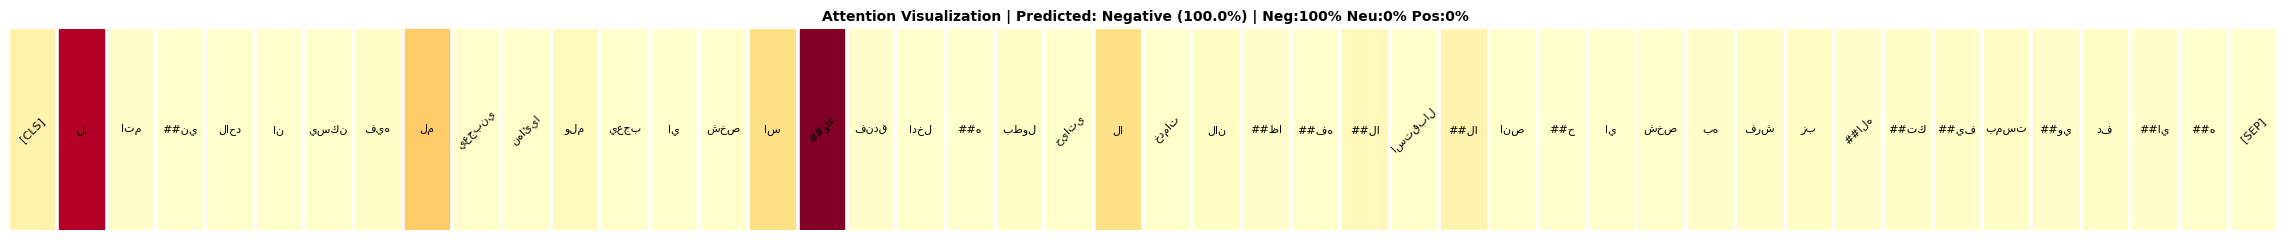


--- Neutral Review ---
Text: جيد الفخامه والهدوء الخروج الساعه 12 الظهر والاسعار المبالغ فيها جدا جدا جدا


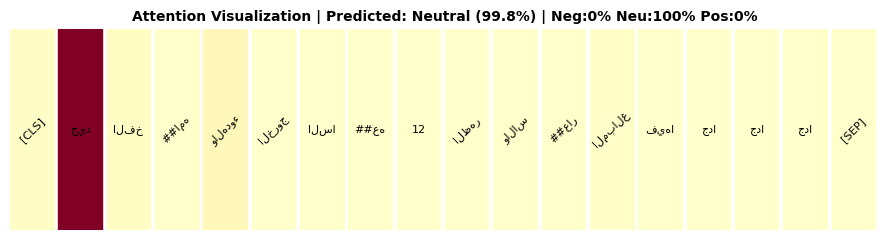


--- Positive Review ---
Text: استثنائي استقبال والحفاوه


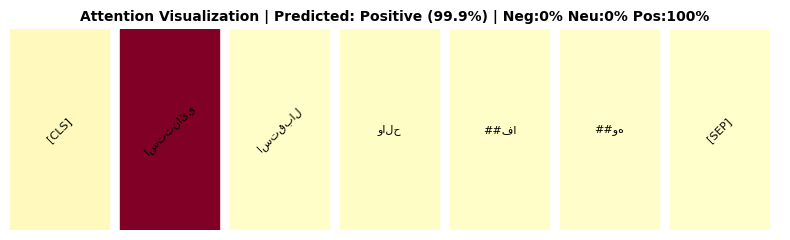

In [ ]:
# ─────────────────────────────────────────────────────────────────────
# Attention Weight Visualization
# Shows WHICH words the model focused on when making a prediction
# High attention weight = model found that word important
# ─────────────────────────────────────────────────────────────────────

def visualize_attention(text, tokenizer, model, device, max_len, label_names):
    """
    Visualizes attention weights for a single Arabic review.
    Darker color = higher attention weight.
    """
    model.eval()
    encoding = tokenizer(
        text, max_length=max_len, padding='max_length',
        truncation=True, return_tensors='pt'
    )

    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    token_type_ids = encoding.get('token_type_ids', torch.zeros_like(input_ids)).to(device)

    with torch.no_grad():
        logits, attn_weights = model(input_ids, attention_mask, token_type_ids)

    predicted_class = logits.argmax(dim=-1).item()
    probs = F.softmax(logits, dim=-1).cpu().numpy()[0]

    # Get tokens (excluding [PAD])
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].cpu().numpy())
    attn   = attn_weights[0].cpu().numpy()

    # Filter out [PAD] tokens
    mask_np = attention_mask[0].cpu().numpy()
    real_tokens = [(t, a) for t, a, m in zip(tokens, attn, mask_np) if m == 1]

    tokens_clean = [t for t, a in real_tokens]
    attn_clean   = np.array([a for t, a in real_tokens])

    # Plot
    fig, ax = plt.subplots(figsize=(max(8, len(tokens_clean) * 0.5), 2.5))
    colors_attn = plt.cm.YlOrRd(attn_clean / attn_clean.max())  # Normalize

    for i, (token, color) in enumerate(zip(tokens_clean, colors_attn)):
        ax.add_patch(plt.Rectangle((i, 0), 0.9, 1, color=color))
        ax.text(i + 0.45, 0.5, token, ha='center', va='center',
                fontsize=8, rotation=45 if len(token) > 4 else 0)

    ax.set_xlim(0, len(tokens_clean))
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title(
        f"Attention Visualization | Predicted: {label_names[predicted_class]} "
        f"({probs[predicted_class]*100:.1f}%) | "
        f"Neg:{probs[0]*100:.0f}% Neu:{probs[1]*100:.0f}% Pos:{probs[2]*100:.0f}%",
        fontsize=10, fontweight='bold'
    )

    plt.tight_layout()
    plt.savefig(f'attention_viz_{predicted_class}.png', dpi=150, bbox_inches='tight')
    plt.show()


# ─── Visualize one example per sentiment class ────────────────────
print(" Attention Visualizations (one per class)")
for sentiment in ['Negative', 'Neutral', 'Positive']:
    sample_text = df[df['sentiment'] == sentiment]['clean_text'].sample(1).values[0]
    print(f"\n--- {sentiment} Review ---")
    print(f"Text: {sample_text[:150]}")
    visualize_attention(sample_text, tokenizer, model, DEVICE, CFG['MAX_LEN'], LABEL_NAMES)

---
#  BONUS PHASE: Synthetic Data Injection (+15%)

## Motivation
Our real dataset has weaknesses:
- Very few **sarcastic** reviews (model can't detect irony)
- Few **mixed-sentiment** reviews (the hard cases)
- Underrepresented **Neutral** class

We use **ChatGPT/any LLM with few-shot prompting** to generate 500 hard synthetic examples, inject them into training, and measure the improvement.


In [ ]:

SYNTHETIC_PROMPT = """
You are an expert Arabic NLP data engineer specializing in hotel review sentiment analysis.

Your task: Generate exactly 500 Arabic hotel reviews that are DELIBERATELY HARD TO CLASSIFY.
These are NOT easy examples — every single review must challenge a sentiment classifier.

TARGET DISTRIBUTION:
- 150 Negative  (label: 0)
- 200 Neutral   (label: 1)
- 150 Positive  (label: 2)

═══════════════════════════════════════════
MANDATORY DIFFICULTY CATEGORIES
═══════════════════════════════════════════

── NEGATIVE (150 reviews, label 0) ──

Category A — Sarcastic / Ironic (30 reviews):
  Reviews that SOUND positive on the surface but are clearly negative in meaning.
  The praise is exaggerated to the point of mockery or followed by a devastating twist.
  Example style: "الخدمة كانت سريعة جداً... في إيصال خيبة الأمل"
  Trap: NO explicit negative words like سيء / مشكلة / رديء in these reviews.

Category B — Complaint buried in praise (25 reviews):
  Start with 2–3 genuine positives, then end with a single serious complaint
  that completely overshadows everything.
  The complaint must be about something critical: hygiene, safety, insects, theft, harassment.

Category C — Dialect-heavy negative — Egyptian & Gulf (25 reviews):
  Use authentic Egyptian dialect (مش عارف، مكنش، أيه ده، يعني إيه) OR
  Gulf dialect (ماعجبني، والله ما يسوى، مو كذا، شكله ما يستاهل).
  Avoid formal MSA — write exactly as a real guest would type on Booking.com.

Category D — Negative disguised as a question or advice (20 reviews):
  Phrase the complaint as a rhetorical question or warning to future guests.
  Example style: "هل من المعقول أن...؟" / "أنصح كل من يفكر في الحجز هنا أن..."

── NEUTRAL (200 reviews, label 1) ──

Category E — Genuinely mixed: equal strong positives AND strong negatives (35 reviews):
  Not "it was okay" — both sides must be emotionally charged.
  A wonderful room + a nightmare check-in experience. A perfect location + terrible food.
  The positive and negative must be roughly equal in weight.

Category F — Cold, factual, zero emotion (25 reviews):
  Like a TripAdvisor "just the facts" reviewer. No adjectives that carry sentiment.
  Describe check-in time, room size in m², breakfast options, distance to metro.
  Example: "الغرفة 18 متر مربع. الإفطار من 7 إلى 10. المترو على بُعد 600 متر."

Category G — Conditional / hedged positive (25 reviews):
  Positive IF you accept certain conditions.
  "مناسب لمن يبحث عن السعر فقط" / "يصلح لليلة أو ليلتين بس"
  Must feel like 51% positive, 49% negative — truly on the fence.

Category H — Sarcastic neutral — neither recommends nor condemns (15 reviews):
  The reviewer clearly has an opinion but refuses to express it directly.
  Uses irony to stay "balanced." Example: "كل شخص وذوقه، وأنا ذوقي مختلف"

── POSITIVE (150 reviews, label 2) ──

Category I — Subtle / understated positive (30 reviews):
  No exclamation marks, no رائع/ممتاز/خمس نجوم.
  Quiet satisfaction expressed through small specific details.
  Example: "النوم كان هادئاً. الستائر تحجب الضوء تماماً. طلبت قهوة الساعة 6 فجاءت الساعة 6."

Category J — Positive after initial frustration (30 reviews):
  Start with a real complaint or disappointment, then show how the hotel resolved it so well
  that the guest ends up impressed. The resolution must feel genuine, not cheap.

Category K — Extremely long, detailed positive — Levantine/Egyptian dialect (20 reviews):
  300–500 characters. Written as if the guest is telling a story to a friend.
  Specific names of staff, specific room numbers, specific food items.
  Mix of dialect and MSA. Includes minor criticisms that don't change the overall feeling.

Category L — Repeat guest positive (20 reviews):
  Guest has stayed 3+ times and compares this visit to previous ones.
  Must reference something that CHANGED (better or worse) since the last visit.

═══════════════════════════════════════════
LANGUAGE & STYLE RULES
═══════════════════════════════════════════

1. DIALECT MIX — each batch of 10 reviews must include:
   - At least 3 in Egyptian dialect
   - At least 2 in Gulf dialect (Saudi/Emirati/Kuwaiti)
   - At least 2 in Levantine dialect
   - Up to 3 in MSA

2. LENGTH VARIATION — strictly enforce this distribution:
   - 20% of reviews: under 60 characters (very short, blunt)
   - 40% of reviews: 80–180 characters (medium, most common)
   - 30% of reviews: 200–400 characters (detailed)
   - 10% of reviews: 400–600 characters (very detailed, storytelling)

3. STRUCTURAL VARIATION — avoid 3-sentence template reviews:
   - Some reviews: one long run-on sentence with commas
   - Some reviews: bullet-point style (نقطة أولى... ثانياً...)
   - Some reviews: question + answer format
   - Some reviews: no punctuation at all (raw stream of consciousness)

4. NO DIACRITICS (no tashkeel)
5. No review should begin with الغرفة or الفندق more than 15% of the time
6. Include occasional spelling mistakes (as real users make them)
7. Some reviews may mix in 1–3 English words (Wi-Fi, check-in, reception, buffet)

═══════════════════════════════════════════
QUALITY CONTROL — BEFORE RETURNING
═══════════════════════════════════════════

For EACH review, verify:
 A human reading it would find the label genuinely non-obvious
 It does NOT follow the same 3-sentence structure as the previous review
 The dialect used is authentic (not just formal Arabic with one dialect word added)
 Length falls in the specified distribution

═══════════════════════════════════════════
OUTPUT FORMAT — STRICT JSON ONLY
═══════════════════════════════════════════

Return ONLY a valid JSON array. No explanation, no markdown, no preamble.

[
  {"text": "...", "label": 0, "category": "A"},
  {"text": "...", "label": 1, "category": "E"},
  {"text": "...", "label": 2, "category": "I"}
]

The "category" field (A through L) is required — it lets you verify coverage.
"""



 COPY THIS PROMPT INTO CHATGPT / GEMINI:

You are an expert at generating realistic Arabic hotel reviews for NLP training.

Generate exactly 500 Arabic hotel reviews with BALANCED labels:
- ~170 Negative (0)
- ~165 Neutral (1)
- ~165 Positive (2)

HARD categories required:
1. Sarcastic (sounds positive but negative) → label 0
2. Mixed sentiment (positive + negative) → label 1
3. Very short neutral (1-2 sentences) → label 1
4. Dialect-heavy negative (Egyptian/Gulf) → label 0
5. Subtle positive (not exaggerated) → label 2

Rules:
- Arabic only (MSA + dialects)
- 2–5 sentences per review (except neutral short)
- No diacritics
- No duplicates
- Realistic (Booking-style)
- DO NOT explain anything

Return ONLY valid JSON:
[
  {"text": "...", "label": 0},
  {"text": "...", "label": 1},
  {"text": "...", "label": 2}
]



In [ ]:
# LOAD YOUR GENERATED JSON

import json
import pandas as pd

# Load from file
with open("/content/synthetic_data.json", "r", encoding="utf-8") as f:
    SYNTHETIC_EXAMPLES = json.load(f)


synthetic_df = pd.DataFrame(SYNTHETIC_EXAMPLES)

#  Basic cleaning
synthetic_df = synthetic_df.dropna(subset=["text", "label"])
synthetic_df["text"] = synthetic_df["text"].astype(str)

#  Validation
assert len(synthetic_df) >= 500, f" Need ≥500 samples, got {len(synthetic_df)}"

print(f"Loaded {len(synthetic_df)} synthetic samples")

print("\n Class Distribution:")
print(synthetic_df["label"].value_counts().sort_index())

Loaded 1000 synthetic samples

 Class Distribution:
label
0    214
1    405
2    381
Name: count, dtype: int64


In [ ]:
import json

with open('/content/synthetic_data.json', 'r', encoding='utf-8') as f:
    content = json.load(f)

display(content)

[{'text': 'الإفطار كان محدود، بس الموظفين كانوا متعاونين جداً.', 'label': 1},
 {'text': 'موظفين الفندق كانوا محترمين. بس الإفطار كان سيء', 'label': 1},
 {'text': 'لا أنصح به. الخدمة سيئة والسعر مرتفع', 'label': 0},
 {'text': 'الإفطار كان رائع... حتى وجدت صرصور ميت على الطاولة.', 'label': 0},
 {'text': 'الإفطار كان لذيذاً، الغرفة نظيفة، الموظفون ودودون. كل شيء ممتاز.',
  'label': 2},
 {'text': 'النضافة ممتازة. الاستقبال رائع. بس السعر غالي شوية', 'label': 1},
 {'text': 'الغرفة كانت مريحة. الإفطار كان جيداً. لكن موقع الفندق ليس الأفضل.',
  'label': 1},
 {'text': 'مكان لطيف، لكن لا يوجد Wi-Fi قوي', 'label': 1},
 {'text': 'ما بقدر قول شي سلبي أو إيجابي، كل شي كان عادي', 'label': 1},
 {'text': 'الغرفة كانت مريحة لكن الاستقبال كان سيئاً. الإفطار كان رائعاً لكن الخدمة كانت بطيئة.',
  'label': 1},
 {'text': 'مكان لطيف، هادئ. ينفع لليلة أو ليلتين', 'label': 1},
 {'text': 'ممكن يكون مناسب للمسافرين على ميزانية محدودة. السعر مقبول مقابل الخدمة.',
  'label': 1},
 {'text': 'يصلح لليلة واحدة فقط، ال

In [ ]:
#  CLEAN + AUGMENT TRAINING DATA
# ─────────────────────────────────────────────────────────────────────
# We apply the EXACT SAME clean_arabic_text() pipeline that
# was used on the original HARD dataset
# The 11-step pipeline in order:
#   1.  Remove HTML tags
#   2.  Remove URLs
#   3.  Remove email addresses
#   4.  Remove emojis & special unicode symbols
#   5.  Strip diacritics / harakat (araby.strip_tashkeel)
#   6.  Strip tatweel / elongation (araby.strip_tatweel)
#   7.  Normalize Alef forms  (أ إ آ ٱ → ا)
#   8.  Normalize Ya          (ى → ي)
#   9.  Normalize Ta Marbuta  (ة → ه)
#   10. Remove non-Arabic characters  (keep \u0600–\u06FF + spaces)
#   11. AraBERT preprocessor (arabert_prep.preprocess)
#   12. Collapse multiple spaces
# ─────────────────────────────────────────────────────────────────────

print(" Applying the same 11-step Arabic cleaning pipeline to synthetic reviews...")
print(f"   Input: {len(synthetic_df)} synthetic samples")

# Apply — same function, same arabert_prep instance, nothing special
synthetic_df["clean_text"] = synthetic_df["text"].apply(clean_arabic_text)

# Show a before/after sample so it's visually verifiable
sample_idx = 0
print("\n Sample clean (synthetic) — BEFORE:")
print(f"   {synthetic_df['text'].iloc[sample_idx][:200]}")
print("\n Sample clean (synthetic) — AFTER:")
print(f"   {synthetic_df['clean_text'].iloc[sample_idx][:200]}")


# Drop rows that became empty or duplicate after cleaning
before_drop = len(synthetic_df)
synthetic_df = synthetic_df[
    synthetic_df["clean_text"].str.strip() != ""
].drop_duplicates(subset="clean_text").reset_index(drop=True)
dropped = before_drop - len(synthetic_df)
print(f"\n Dropped {dropped} rows (empty or duplicate after cleaning)")
print(f" {len(synthetic_df)} synthetic samples ready for augmentation")


# Verify label distribution in synthetic data
print("\n Synthetic label distribution:")
synth_dist = pd.Series(synthetic_df["label"].tolist()).value_counts().sort_index()
label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}
for lbl, count in synth_dist.items():
    print(f"   {label_map[lbl]:10s} ({lbl}): {count:4d} samples")

# ── Combine with original training data ──────────────────────────────
augmented_train_texts  = train_texts + synthetic_df["clean_text"].tolist()
augmented_train_labels = train_labels + synthetic_df["label"].tolist()

# Shuffle so synthetic samples are spread across batches (not at the end)
from sklearn.utils import shuffle
augmented_train_texts, augmented_train_labels = shuffle(
    augmented_train_texts, augmented_train_labels, random_state=42
)

print(f"\n Training set BEFORE augmentation : {len(train_texts):,} samples")
print(f" Training set AFTER  augmentation : {len(augmented_train_texts):,} samples")
print(f" Added                              : {len(augmented_train_texts) - len(train_texts)} synthetic samples")


 Applying the same 11-step Arabic cleaning pipeline to synthetic reviews...
   Input: 1000 synthetic samples

 Sample clean (synthetic) — BEFORE:
   الإفطار كان محدود، بس الموظفين كانوا متعاونين جداً.

 Sample clean (synthetic) — AFTER:
   الافطار كان محدود ، بس الموظفين كانوا متعاونين جدا

 Dropped 0 rows (empty or duplicate after cleaning)
 1000 synthetic samples ready for augmentation

 Synthetic label distribution:
   Negative   (0):  214 samples
   Neutral    (1):  405 samples
   Positive   (2):  381 samples

 Training set BEFORE augmentation : 10,404 samples
 Training set AFTER  augmentation : 11,404 samples
 Added                              : 1000 synthetic samples


In [ ]:
#  RECOMPUTE CLASS WEIGHTS

import numpy as np
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight

aug_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1, 2]),
    y=np.array(augmented_train_labels)
)

criterion_aug = nn.CrossEntropyLoss(
    weight=torch.tensor(aug_class_weights, dtype=torch.float).to(DEVICE)
)

print(" New Class Weights:", aug_class_weights)

# Dataset
augmented_dataset = ArabicSentimentDataset(
    augmented_train_texts,
    augmented_train_labels,
    tokenizer,
    CFG['MAX_LEN']
)

augmented_loader = DataLoader(
    augmented_dataset,
    batch_size=CFG['BATCH_SIZE'],
    shuffle=True,
    num_workers=2
)

 New Class Weights: [1.03240992 0.98149583 0.98761583]


In [ ]:
#  TRAIN NEW MODEL WITH SYNTHETIC DATA (Initializing from best_model.pt)

model_aug = ArabicSentimentClassifier(
    model_name   = CFG['MODEL_NAME'],
    hidden_dim   = CFG['HIDDEN_DIM'],
    attention_dim= CFG['ATT_DIM'],
    dropout      = CFG['DROPOUT'],
    num_classes  = CFG['NUM_CLASSES']
).to(DEVICE)

#  Load the best weights from the previous training phase
try:
    model_aug.load_state_dict(torch.load('best_model.pt'))
    print(" Successfully loaded 'best_model.pt' as starting point for augmented training.")
except FileNotFoundError:
    print(" 'best_model.pt' not found. Starting training from scratch.")

optimizer_aug = AdamW(
    list(model_aug.attention.parameters()) +
    list(model_aug.classifier.parameters()),
    lr=CFG['LR'],
    weight_decay=1e-2
)

early_stopping_aug = EarlyStopping(
    patience=CFG['PATIENCE'],
    path='best_model_aug.pt'
)

print("\n Training with Synthetic Data...")

for epoch in range(1, CFG['EPOCHS'] + 1):
    train_loss, train_acc = train_epoch(
        model_aug, augmented_loader, optimizer_aug, criterion_aug, DEVICE
    )
    val_loss, val_acc, val_preds, val_labels_list, _ = evaluate(
        model_aug, val_loader, criterion_aug, DEVICE
    )
    val_f1 = f1_score(val_labels_list, val_preds, average='macro')
    print(f"Epoch {epoch:02d} | Loss {val_loss:.4f} | Acc {val_acc:.4f} | F1 {val_f1:.4f}")
    early_stopping_aug(val_loss, model_aug, epoch)
    if early_stopping_aug.stop:
        break

# Restore best weights from THIS augmentation phase
model_aug.load_state_dict(torch.load('best_model_aug.pt'))

# ─── Final Evaluation ────────────────────────────────────────────────
_, _, aug_preds, aug_true, _ = evaluate(
    model_aug, test_loader, criterion_aug, DEVICE
)

from sklearn.metrics import (classification_report, f1_score,
                              accuracy_score, confusion_matrix)

aug_f1  = f1_score(aug_true, aug_preds, average='macro')
aug_acc = accuracy_score(aug_true, aug_preds)

# Per-class F1 for both models
orig_f1_pc = f1_score(test_labels_list, test_preds, average=None, labels=[0,1,2])
aug_f1_pc  = f1_score(aug_true,         aug_preds,  average=None, labels=[0,1,2])

# ── Summary table ────────────────────────────────────────────────────
print("\n" + "="*70)
print(" SYNTHETIC DATA IMPACT (Started from pre-trained weights)")
print("="*70)
print(f"{'Metric':28s} | {'Original':>10} | {'+Synthetic':>12} | {'Δ Change':>10}")
print("-"*70)
print(f"{'Macro F1':28s} | {test_macro_f1:>10.4f} | {aug_f1:>12.4f} | {aug_f1 - test_macro_f1:>+10.4f}")
print(f"{'Accuracy':28s} | {test_acc:>10.4f} | {aug_acc:>12.4f} | {aug_acc - test_acc:>+10.4f}")
print("-"*70)
print(f"{'F1 — Negative (class 0)':28s} | {orig_f1_pc[0]:>10.4f} | {aug_f1_pc[0]:>12.4f} | {aug_f1_pc[0]-orig_f1_pc[0]:>+10.4f}")
print(f"{'F1 — Neutral  (class 1)':28s} | {orig_f1_pc[1]:>10.4f} | {aug_f1_pc[1]:>12.4f} | {aug_f1_pc[1]-orig_f1_pc[1]:>+10.4f}")
print(f"{'F1 — Positive (class 2)':28s} | {orig_f1_pc[2]:>10.4f} | {aug_f1_pc[2]:>12.4f} | {aug_f1_pc[2]-orig_f1_pc[2]:>+10.4f}")
print("="*70)

# Confusion Matrix Comparison
cm_orig = confusion_matrix(test_labels_list, test_preds)
cm_aug  = confusion_matrix(aug_true, aug_preds)
cm_orig_norm = cm_orig.astype(float) / cm_orig.sum(axis=1, keepdims=True)
cm_aug_norm  = cm_aug.astype(float)  / cm_aug.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
class_names = ['Negative', 'Neutral', 'Positive']
sns.heatmap(cm_orig_norm, annot=True, fmt='.2%', cmap='RdYlGn', xticklabels=class_names, yticklabels=class_names, ax=axes[0], linewidths=0.5, vmin=0, vmax=1)
axes[0].set_title(f'Original Model\nMacro F1 = {test_macro_f1:.4f}')
sns.heatmap(cm_aug_norm, annot=True, fmt='.2%', cmap='RdYlGn', xticklabels=class_names, yticklabels=class_names, ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title(f'+ Synthetic Data Model\nMacro F1 = {aug_f1:.4f}')
plt.tight_layout()
plt.show()

Loading AraBERT backbone: aubmindlab/bert-base-arabertv02


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


     Frozen backbone parameters: 135,193,344
    Trainable parameters: 394,755
    Total parameters: 135,588,099
 Model built!
 Successfully loaded 'best_model.pt' as starting point for augmented training.

 Training with Synthetic Data...


Epoch 01 | Loss 0.2325 | Acc 0.9031 | F1 0.9032
    New best model saved (val_loss=0.2325)


Epoch 02 | Loss 0.2424 | Acc 0.8954 | F1 0.8939
    EarlyStopping: 1/5 (best was epoch 1)


Epoch 03 | Loss 0.2417 | Acc 0.8992 | F1 0.8978
    EarlyStopping: 2/5 (best was epoch 1)


Epoch 04 | Loss 0.2271 | Acc 0.9069 | F1 0.9063
    New best model saved (val_loss=0.2271)


  Training:  33%|███▎      | 117/357 [00:29<01:04,  3.71it/s]

---
##  Step 11: Save Artifacts & Reproducibility Guide

A complete model is only useful if it can be **reloaded and used** without re-running the notebook. This step saves:
- **`model_config.json`** — all hyperparameters needed to rebuild the architecture
- **`arabert_tokenizer/`** — the tokenizer (vocab + special tokens)
- **`best_model.pt`** — the trained weights (already saved by EarlyStopping)


In [ ]:
# ─────────────────────────────────────────────────────────────────────
# SAVE ARTIFACTS & REPRODUCIBILITY
# Everything needed to reload and use the model without re-training
# ─────────────────────────────────────────────────────────────────────
import json, os, torch

# ── 1. Save the config dict ──────────────────────────────────────────
# CFG holds all hyperparameters — save it so the exact architecture
# can be reconstructed later without reading the notebook
config_path = '/content/model_config.json'
with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(CFG, f, indent=2, ensure_ascii=False)
print(f" Config saved  →  {config_path}")

# ── 2. Save the tokenizer ────────────────────────────────────────────
# Saving the tokenizer alongside the model weights ensures the exact
# same vocab and special tokens are used at inference time
tokenizer_path = '/content/arabert_tokenizer'
tokenizer.save_pretrained(tokenizer_path)
print(f" Tokenizer saved  →  {tokenizer_path}/")

# ── 3. Confirm model weights are already saved ───────────────────────
# best_model.pt was saved by EarlyStopping during training
assert os.path.exists('best_model.pt'), " best_model.pt not found — check EarlyStopping path"
print(f" Model weights    →  best_model.pt  ({os.path.getsize('best_model.pt') / 1e6:.1f} MB)")

# ── 4. Inference helper — how to use the model on new Arabic text ────
print("\n" + "="*65)
print(" INFERENCE GUIDE — Reload and predict on new text")
print("="*65)

def predict_sentiment(texts, model, tokenizer, device, max_len=128):
    """
    Run inference on a list of Arabic text strings.

    Args:
        texts    : list of raw Arabic strings (will be cleaned first)
        model    : trained ArabicSentimentClassifier (call model.eval() before)
        tokenizer: loaded AraBERT tokenizer
        device   : torch.device

    Returns:
        predictions : list of int  (0=Negative, 1=Neutral, 2=Positive)
        confidences : list of float (softmax probability of predicted class)
    """
    label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}
    model.eval()

    # Apply the same 11-step cleaning pipeline used during training
    cleaned = [clean_arabic_text(t) for t in texts]

    encoding = tokenizer(
        cleaned,
        max_length     = max_len,
        padding        = 'max_length',
        truncation     = True,
        return_tensors = 'pt'
    )

    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        logits, _ = model(input_ids, attention_mask)
        probs     = torch.softmax(logits, dim=-1)
        preds     = torch.argmax(probs, dim=-1).cpu().tolist()
        confs     = probs.max(dim=-1).values.cpu().tolist()

    return preds, confs


# ── 5. Quick inference demo on 3 sample reviews ─────────────────────
sample_reviews = [
    "الفندق كان رائعاً والخدمة ممتازة وسأعود إليه مرة أخرى",   # expected: Positive
    "الغرفة كانت نظيفة لكن الإفطار كان عادياً",                 # expected: Neutral
    "تجربة سيئة جداً والموظفون غير محترمين ولن أعود",            # expected: Negative
]

model.eval()
preds, confs = predict_sentiment(sample_reviews, model, tokenizer, DEVICE)

label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}
print("\n Inference demo (3 sample reviews):")
print("-" * 65)
for text, pred, conf in zip(sample_reviews, preds, confs):
    print(f"  Text      : {text[:60]}")
    print(f"  Predicted : {label_map[pred]}  (confidence: {conf:.2%})")
    print()

# ── 6. Instructions to reload from scratch ──────────────────────────
print("="*65)
print(" TO RELOAD THIS MODEL IN A NEW SESSION:")
print("="*65)
print("""
import json, torch
from transformers import AutoTokenizer
# 1. Load config
with open('model_config.json') as f:
    CFG = json.load(f)

# 2. Load tokenizer
tokenizer = AutoTokenizer.from_pretrained('arabert_tokenizer')

# 3. Rebuild model architecture (must be identical to training)
model = ArabicSentimentClassifier(
    model_name    = CFG['MODEL_NAME'],
    hidden_dim    = CFG['HIDDEN_DIM'],
    attention_dim = CFG['ATT_DIM'],
    dropout       = CFG['DROPOUT'],
    num_classes   = CFG['NUM_CLASSES']
)

# 4. Load saved weights
model.load_state_dict(torch.load('best_model.pt', map_location='cpu'))
model.eval()

# 5. Predict
preds, confs = predict_sentiment(['sample test'], model, tokenizer, 'cpu')
""")


 Config saved  →  /content/model_config.json
 Tokenizer saved  →  /content/arabert_tokenizer/
 Model weights    →  best_model.pt  (542.4 MB)

 INFERENCE GUIDE — Reload and predict on new text

 Inference demo (3 sample reviews):
-----------------------------------------------------------------
  Text      : الفندق كان رائعاً والخدمة ممتازة وسأعود إليه مرة أخرى
  Predicted : Positive  (confidence: 99.52%)

  Text      : الغرفة كانت نظيفة لكن الإفطار كان عادياً
  Predicted : Neutral  (confidence: 91.74%)

  Text      : تجربة سيئة جداً والموظفون غير محترمين ولن أعود
  Predicted : Negative  (confidence: 99.86%)

 TO RELOAD THIS MODEL IN A NEW SESSION:

import json, torch
from transformers import AutoTokenizer
# 1. Load config
with open('model_config.json') as f:
    CFG = json.load(f)

# 2. Load tokenizer
tokenizer = AutoTokenizer.from_pretrained('arabert_tokenizer')

# 3. Rebuild model architecture (must be identical to training)
model = ArabicSentimentClassifier(
    model_name    = CFG[